## IMPORT DATESET

In [30]:
import pandas as pd
import numpy as np

df = pd.read_csv("Superstore sales.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Product catalog

In [46]:
df["Sub-Category"].value_counts().head(10)

Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Name: count, dtype: int64

## Product Category has max profit

In [32]:
df[df["Profit"].notnull()].groupby("Category")["Profit"].sum().sort_values(ascending=False).head()

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

## Type segment bring to more profit

In [33]:
df.groupby("Segment")["Profit"].sum().sort_values(ascending=False).head()

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

## Shipping Duration

In [34]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df["Shipping_duration"] = (df["Ship Date"] - df["Order Date"]).dt.days
df.groupby("Ship Mode")["Shipping_duration"].mean().sort_values().round(2).head()

Ship Mode
Same Day          0.04
First Class       2.18
Second Class      3.24
Standard Class    5.01
Name: Shipping_duration, dtype: float64

## Revenue of Regions

In [35]:
df.groupby(["Region", "Category"])["Sales"].sum().sort_values(ascending=False).head(10).reset_index()

,Region,Category,Sales
0,East,Technology,264973.9810
1,West,Furniture,252612.7435
2,West,Technology,251991.8320
3,West,Office Supplies,220853.2490
4,East,Furniture,208291.2040
5,East,Office Supplies,205516.0550
6,Central,Technology,170416.3120
7,Central,Office Supplies,167026.4150
8,Central,Furniture,163797.1638
9,South,Technology,148771.9080


## Top customers by purchase

In [36]:
df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).reset_index

<bound method Series.reset_index of Customer Name
Sean Miller        25043.050
Tamara Chand       19052.218
Raymond Buch       15117.339
Tom Ashbrook       14595.620
Adrian Barton      14473.571
                     ...    
Roy Skaria            22.328
Mitch Gastineau       16.739
Carl Jackson          16.520
Lela Donovan           5.304
Thais Sissman          4.833
Name: Sales, Length: 793, dtype: float64>

## Correlation between Discount and Profit

In [37]:
df.groupby(["Sub-Category","Discount"])["Profit"].mean().sort_values().head(10).reset_index()

,Sub-Category,Discount,Profit
0,Machines,0.70,-851.274743
1,Machines,0.50,-636.269092
2,Bookcases,0.70,-259.662627
3,Tables,0.50,-239.316314
4,Bookcases,0.50,-236.433983
5,Tables,0.45,-226.646464
6,Tables,0.40,-215.831957
7,Machines,0.40,-205.141800
8,Appliances,0.80,-128.800615
9,Binders,0.80,-94.031751


## Draw chart

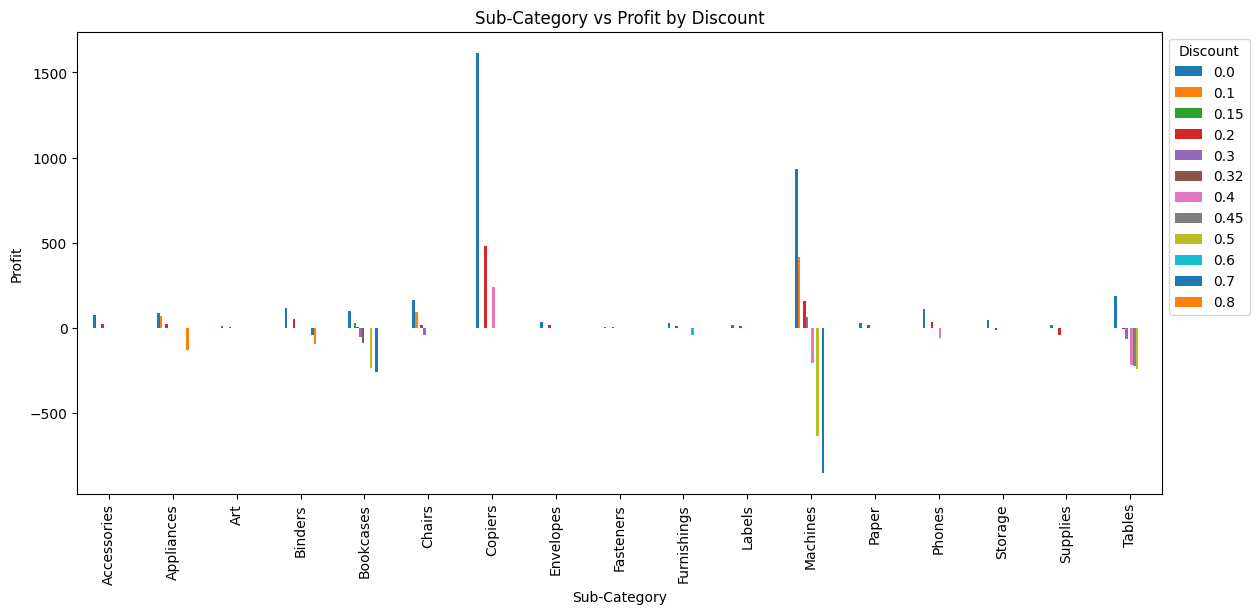

In [45]:
import matplotlib.pyplot as plt

df.groupby(["Sub-Category", "Discount"])["Profit"].mean().unstack().plot(kind="bar", figsize=(14,6))
plt.title("Sub-Category vs Profit by Discount")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.legend(title="Discount", bbox_to_anchor=(1,1))
plt.show()
